# <font color="#0b486b">  FIT5215: Deep Learning (2026)</font>
***

Faculty of Information Technology, Monash University, Australia
***

## <font color="#0b486b">Part 2: Deep Neural Networks (DNN) </font>

The second part of this assignment is to demonstrate your basis knowledge in deep learning that you have acquired from the lectures and tutorials materials. Most of the contents in this assignment are drawn from **the tutorials covered from weeks 1 to 2**. Going through these materials before attempting this assignment is highly recommended.

In the second part of this assignment, you are going to work with the FashionMNIST dataset for the image recognition task. It has the exact same format as MNIST (70,000 grayscale images of 28 × 28 pixels each with 10 classes), but the images represent fashion items rather than handwritten digits, so each class is more diverse, and the problem is significantly more challenging than MNIST.

In [1]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

torch.manual_seed(1234)

**Load the Fashion MNIST using `torchvision`**

In [2]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])  # Convert to tensor, then adjust pixels to roughly -1 to 1

train_dataset_orgin = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)  # 60000 training images
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)  # 10000 test images

print(train_dataset_orgin.data.shape, train_dataset_orgin.targets.shape)  # [60000,28,28], [60000]
print(test_dataset.data.shape, test_dataset.targets.shape)  # [10000,28,28], [10000]

# Flatten the data
train_dataset_orgin.data = train_dataset_orgin.data.reshape(-1, 28*28)  # Flatten each 28x28 image into 784
test_dataset.data = test_dataset.data.reshape(-1, 28*28)  # Flatten test images into 784 as well

print(train_dataset_orgin.data.shape, train_dataset_orgin.targets.shape)  # [60000,784], [60000]
print(test_dataset.data.shape, test_dataset.targets.shape)  # [10000,784], [10000]

N = len(train_dataset_orgin)  # Total of 60000 training images
print(f"Number of training samples: {N}")
N_train = int(0.9*N)  # 90%, meaning 54000 images for training
N_val = N - N_train  # The remaining 6000 images for validation
print(f"Number of training samples: {N_train}")
print(f"Number of validation samples: {N_val}")

train_dataset, val_dataset = torch.utils.data.random_split(train_dataset_orgin, [N_train, N_val])  # Randomly split into training and validation sets


print(len(train_dataset))  # 54000
print(len(val_dataset))  # 6000


train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)  # Batch size of 64 during training and shuffle the data
val_loader = DataLoader(dataset=val_dataset, batch_size=64, shuffle=False)  # Batch size of 64 during validation; validation and test sets only evaluate the model's performance without updating parameters
test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)  # Batch size of 1000 during testing

torch.Size([60000, 28, 28]) torch.Size([60000])
torch.Size([10000, 28, 28]) torch.Size([10000])
torch.Size([60000, 784]) torch.Size([60000])
torch.Size([10000, 784]) torch.Size([10000])
Number of training samples: 60000
Number of training samples: 54000
Number of validation samples: 6000
54000
6000


####  <font color="red">**Question 2.1:**</font> Write the code to visualize a mini-batch in `train_loader` including its images and labels.



In [3]:
print(train_dataset_orgin.classes)   # Let the computer open the toy box and read out the names of these 10 classes

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


torch.Size([64, 1, 784, 1])


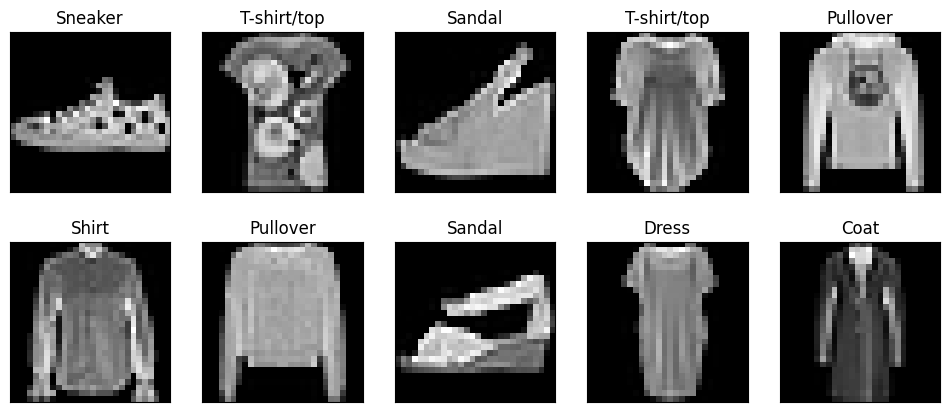

In [4]:
import matplotlib.pyplot as plt
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 1. Get a batch from train_loader: 64 images, and display the first 10 of them
dataiter = iter(train_loader)
images, labels = next(dataiter)
print(images.shape)

# 2. Prepare a large canvas to display the first 10 images, drawing them one by one
fig = plt.figure(figsize=(12, 5))  
for i in range(10):
    ax = fig.add_subplot(2, 5, i + 1, xticks=[], yticks=[])    # Draw a 2x5 grid of subplots without axis ticks; fig.add_subplot() requires the index to start from 1 (position 1, position 2... up to position 10)

    img = images[i].view(28, 28).numpy()   # The images were previously flattened (into a 784-length array) during data processing, so reshape them back to 28x28 square images here
    img = img * 0.5 + 0.5    # Restore the original colors (since transforms.Normalize((0.5,), (0.5,)) previously forced the pixel values into the [-1, 1] range)
    
    # Display the grayscale image and set its title to the corresponding clothing name
    ax.imshow(img, cmap='gray')
    ax.set_title(class_names[labels[i].item()])

plt.show()

#### <font color="red">**Question 2.2:**</font> Write the code for the feed-forward neural net using PyTorch



We now develop a feed-forward neural network with the architecture $784 \rightarrow 40(ReLU) \rightarrow 30(ReLU) \rightarrow 10(softmax)$. You can choose your own way to implement your network and an optimizer of interest. You should train model in $50$ epochs and evaluate the trained model on the test set.

In [5]:
import torch.nn as nn
import torch.optim as optim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   # Switch to GPU 
print("Device:", device)

Device: cuda


In [6]:
# Q2.2: Define a feedforward neural network 784 -> 40(ReLU) -> 30(ReLU) -> 10(Softmax)
# Image -> Flatten -> FC1 -> ReLU -> FC2 -> ReLU -> FC3
class DeepNeuralNetwork(nn.Module):
    def __init__(self):
        super(DeepNeuralNetwork, self).__init__()
        
        self.flatten = nn.Flatten(start_dim=1)  # Flatten each image into 784 pixels
        self.fc1 = nn.Linear(784, 40)   # 784 pixels -> 40 hidden features
        self.fc2 = nn.Linear(40, 30)    # 40 features -> 30 hidden features
        self.fc3 = nn.Linear(30, 10)    # 30 features -> 10 classification scores
        self.relu = nn.ReLU()           # Define ReLU activation function

    def forward(self, x):
        x = self.flatten(x)              # Reshape input to [batch_size, 784]
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        logits = self.fc3(x)             # Output raw scores for the 10 classes
        return logits

dnn_model = DeepNeuralNetwork().to(device)   # Initialize the model and move it to GPU or CPU
criterion = nn.CrossEntropyLoss()  # Define Cross-Entropy loss function
optimizer = optim.Adam(dnn_model.parameters(), lr=0.001)    # Adam optimizer: Adam ≈ Momentum's "remembering previous directions" + AdaGrad's "automatically adjusting steps for each parameter"

# Train the model for 50 epochs
epochs = 50
for epoch in range(epochs):
    dnn_model.train()   # Enter training mode now
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)  # Move the current batch of data to GPU or CPU

        optimizer.zero_grad()                  # Clear gradients from the previous mini-batch (64 samples)
        logits = dnn_model(images)             # Forward pass to get raw scores for the 10 classes
        loss = criterion(logits, labels)       # Calculate loss using Cross-Entropy
        loss.backward()                        # Backward pass to compute gradients
        optimizer.step()                       # Update model parameters

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")    # Print current epoch and loss after each training step

# Evaluate the model on the test set
dnn_model.eval()    # Tell the model: it's exam mode now (evaluation mode)
correct = 0
total = 0

with torch.no_grad():    # Disable gradient calculation, so W and b will not be trained or updated
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        logits = dnn_model(images)                         # Get raw scores for the 10 classes
        predictions = torch.argmax(logits, dim=1)          # Select the class with the highest score
        correct += (predictions == labels).sum().item()    # Accumulate the number of correct predictions
        total += labels.size(0)                            # Accumulate the total number of test images

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Epoch [1/50], Loss: 2.3156
Epoch [1/50], Loss: 2.2619
Epoch [1/50], Loss: 2.2620
Epoch [1/50], Loss: 2.2068
Epoch [1/50], Loss: 2.1726
Epoch [1/50], Loss: 2.1443
Epoch [1/50], Loss: 2.1022
Epoch [1/50], Loss: 2.1727
Epoch [1/50], Loss: 2.0857
Epoch [1/50], Loss: 2.0530
Epoch [1/50], Loss: 2.0051
Epoch [1/50], Loss: 1.9965
Epoch [1/50], Loss: 1.9338
Epoch [1/50], Loss: 1.9746
Epoch [1/50], Loss: 1.9720
Epoch [1/50], Loss: 1.9621
Epoch [1/50], Loss: 1.8987
Epoch [1/50], Loss: 1.7600
Epoch [1/50], Loss: 1.7510
Epoch [1/50], Loss: 1.8927
Epoch [1/50], Loss: 1.6678
Epoch [1/50], Loss: 1.7271
Epoch [1/50], Loss: 1.6126
Epoch [1/50], Loss: 1.5126
Epoch [1/50], Loss: 1.5557
Epoch [1/50], Loss: 1.4742
Epoch [1/50], Loss: 1.4740
Epoch [1/50], Loss: 1.5030
Epoch [1/50], Loss: 1.3072
Epoch [1/50], Loss: 1.4486
Epoch [1/50], Loss: 1.3631
Epoch [1/50], Loss: 1.3288
Epoch [1/50], Loss: 1.2432
Epoch [1/50], Loss: 1.3914
Epoch [1/50], Loss: 1.3652
Epoch [1/50], Loss: 1.2577
Epoch [1/50], Loss: 1.2701
E

####  <font color="red">**Question 2.3:**</font> Tuning hyper-parameters with grid search


Assume that you need to tune the number of neurons on the first and second hidden layers $n_1 \in \{20, 40\}$, $n_2 \in \{20, 40\}$  and the used activation function  $act \in \{sigmoid, tanh, relu\}$. The network has the architecture pattern $784 \rightarrow n_1 (act) \rightarrow n_2(act) \rightarrow 10(softmax)$ where $n_1, n_2$, and $act$ are in their grides. Write the code to tune the hyper-parameters $n_1, n_2$, and $act$. Note that you can freely choose the optimizer and learning rate of interest for this task.

In [7]:
# Q2.3: Grid search for hyperparameter tuning, testing different combinations of neuron counts and activation functions
# Supports dynamically changing the number of neurons (n1, n2) and activation function (act_name)
class GridSearchNN(nn.Module):
    def __init__(self, n1, n2, act_name):
        super(GridSearchNN, self).__init__()
        self.flatten = nn.Flatten(start_dim=1)  # Flatten each image into 784 pixels
        # Select the corresponding activation function based on the passed name
        if act_name == 'relu':
            self.act = nn.ReLU()
        elif act_name == 'sigmoid':
            self.act = nn.Sigmoid()
        elif act_name == 'tanh':
            self.act = nn.Tanh()
            
        self.fc1 = nn.Linear(784, n1)   # 784 pixels -> n1 hidden features
        self.fc2 = nn.Linear(n1, n2)    # n1 features -> n2 hidden features
        self.fc3 = nn.Linear(n2, 10)    # n2 features -> 10 classification scores
        
    def forward(self, x):
        x = self.flatten(x)             # Reshape input to [batch_size, 784]
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        logits = self.fc3(x)            # Output raw scores for the 10 classes
        return logits

# Start iterating through the parameters given in the question
n1_list = [20, 40]
n2_list = [20, 40]
act_list = ['sigmoid', 'tanh', 'relu']

best_acc = 0
best_config = None
criterion = nn.CrossEntropyLoss()       # Define Cross-Entropy loss function (Softmax is already included internally)

for n1 in n1_list:    # Iterate through each number of neurons in n1_list, e.g., (20,20,relu), (20,40,tanh), (40,40,sigmoid), etc. Loss (error) is like "your degree of hesitation when answering questions (certainty)"
    for n2 in n2_list:    # Iterate through each number of neurons in n2_list
        for act in act_list:
            print(f"Testing Config -> n1: {n1}, n2: {n2}, act: {act}")
            
            # Initialize the model with the current parameter combination and move it to GPU or CPU
            model = GridSearchNN(n1, n2, act).to(device)
            optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer
            
            epochs = 10  # Train each parameter combination for 10 epochs first for grid search comparison
            for epoch in range(epochs):
                model.train()           # Enter training mode
                for images, labels in train_loader:
                    images, labels = images.to(device), labels.to(device)    # Move the current batch of data to GPU or CPU
                    
                    optimizer.zero_grad()               # Clear gradients from the previous batch
                    logits = model(images)              # Forward pass to get raw scores
                    loss = criterion(logits, labels)    # Calculate loss using Cross-Entropy
                    loss.backward()                     # Backward pass to compute gradients
                    optimizer.step()                    # Update model parameters
            
            # Evaluate the model on the validation set directly after running
            model.eval()                # Enter exam mode (evaluation mode)
            correct = 0
            total = 0
            with torch.no_grad():       # Disable gradient calculation, no parameter updates
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    
                    logits = model(images)                                      # Get raw scores for the 10 classes
                    predictions = torch.argmax(logits, dim=1)                   # Select the class with the highest score
                    correct += (predictions == labels).sum().item()             # Accumulate the number of correct predictions
                    total += labels.size(0)                                     # Accumulate the total number of test images
            
            acc = correct / total
            print(f"Validation Accuracy: {acc * 100:.2f}%\n")
            
            # Record the highest validation set accuracy and the corresponding parameter recipe
            if acc > best_acc:
                best_acc = acc
                best_config = (n1, n2, act)

print(f"Best Config: n1={best_config[0]}, n2={best_config[1]}, act={best_config[2]} with Accuracy: {best_acc*100:.2f}%")

Testing Config -> n1: 20, n2: 20, act: sigmoid
Validation Accuracy: 85.77%

Testing Config -> n1: 20, n2: 20, act: tanh
Validation Accuracy: 85.78%

Testing Config -> n1: 20, n2: 20, act: relu
Validation Accuracy: 85.63%

Testing Config -> n1: 20, n2: 40, act: sigmoid
Validation Accuracy: 85.80%

Testing Config -> n1: 20, n2: 40, act: tanh
Validation Accuracy: 86.20%

Testing Config -> n1: 20, n2: 40, act: relu
Validation Accuracy: 86.05%

Testing Config -> n1: 40, n2: 20, act: sigmoid
Validation Accuracy: 86.42%

Testing Config -> n1: 40, n2: 20, act: tanh
Validation Accuracy: 86.87%

Testing Config -> n1: 40, n2: 20, act: relu
Validation Accuracy: 87.23%

Testing Config -> n1: 40, n2: 40, act: sigmoid
Validation Accuracy: 86.65%

Testing Config -> n1: 40, n2: 40, act: tanh
Validation Accuracy: 86.90%

Testing Config -> n1: 40, n2: 40, act: relu
Validation Accuracy: 87.90%

Best Config: n1=40, n2=40, act=relu with Accuracy: 87.90%


####  <font color="red">**Question 2.4:**</font> Implement the loss with the form: $loss(p,y)=CE(1_{y},p)+\lambda H(p)$ where $H(p)=-\sum_{i=1}^{M}p_{i}\log p_{i}$ is the entropy of $p$, $p$ is the prediction probabilities of a data point $x$ with the ground-truth label $y$, $1_y$ is an one-hot label, and $\lambda >0$ is a trade-off parameter. Set $\lambda = 0.1$ to train a model.



In [8]:
# Q2.4: Custom loss function with information entropy regularization term
# 1. Scoring formula required by the question: Loss = CE (Cross Entropy) (checked the standard answer) + lambda * H (Information Entropy) (penalty for hesitation)
# Information entropy H(p): A metric used to calculate "how messy or hesitant the system is", H(p) = - Σ p(x) log(p(x)), where p(x) is the predicted probability distribution of the model for each class
def custom_loss_with_entropy(logits, labels, lam=0.1):
    # Part 1: Directly use the stable Cross Entropy to calculate the base loss
    ce_loss = nn.CrossEntropyLoss()(logits, labels)
    p = torch.softmax(logits, dim=1)    # Convert the raw scores (logits) into a probability distribution (p) to calculate the information entropy
    
    # Part 2: Calculate the information entropy formula H(p)
    entropy = - torch.sum(p * torch.log(p + 1e-8), dim=1).mean()  # Calculate the entropy for each sample, then take the average; 1e-8 is added to avoid log(0)
    
    # Part 3: Add the two parts together using lambda
    return ce_loss + lam * entropy

# 2. Use the existing blueprint from Q2.2 directly to build a new model, and move it to GPU or CPU
dnn_model_24 = DeepNeuralNetwork().to(device)
optimizer = optim.Adam(dnn_model_24.parameters(), lr=0.001)  # Adam optimizer

# Train the model for 50 epochs
epochs = 50
for epoch in range(epochs):
    dnn_model_24.train()    # Enter training mode
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)  # Move to GPU or CPU
        
        optimizer.zero_grad()               # Clear gradients from the previous batch
        logits = dnn_model_24(images)           # Forward pass to get raw scores for the 10 classes
        
        # 3. Use the custom loss function to score, passing in logits; the question requires lam=0.1
        loss = custom_loss_with_entropy(logits, labels, lam=0.1)
        
        loss.backward()                     # Backward pass to compute gradients
        optimizer.step()                    # Update model parameters
        
    if (epoch + 1) % 10 == 0:   # Print the current epoch number and loss every 10 epochs of training
        print(f"Epoch [{epoch+1}/{epochs}], Custom Loss: {loss.item():.4f}")

# Evaluate the model on the test set
dnn_model_24.eval()     # Tell the model: it's exam mode now (evaluation mode)
correct = 0
total = 0

with torch.no_grad():    # Disable gradient calculation
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        logits = dnn_model_24(images)                          # Get raw scores
        predictions = torch.argmax(logits, dim=1)          # Select the class with the highest score
        correct += (predictions == labels).sum().item()    # Accumulate the number of correct predictions
        total += labels.size(0)                            # Accumulate the total number of test images

print(f"Q2.4 Test Accuracy: {100 * correct / total:.2f}%")

Epoch [10/50], Custom Loss: 0.2539
Epoch [20/50], Custom Loss: 0.2111
Epoch [30/50], Custom Loss: 0.1836
Epoch [40/50], Custom Loss: 0.1641
Epoch [50/50], Custom Loss: 0.2405
Q2.4 Test Accuracy: 87.66%


####  <font color="red">**Question 2.5:**</font> Experimenting with **sharpness-aware minimization** technique

Sharpness-aware minimization (SAM) (i.e., [link for main paper](https://arxiv.org/pdf/2010.01412) from Google Deepmind) is a simple yet but efficient technique to improve the generalization ability of deep learning models on unseen data examples. In your research or your work, you might potentially use this idea. Your task is to read the paper and implement *Sharpness-aware minimization (SAM)*. Finally, you need to apply SAM to the best architecture found in **Question 2.3**.   

In [9]:
# ==========================================
# Q2.5: Experimenting with SAM (Sharpness-Aware Minimization)
# ==========================================
# Core sequence of SAM: Calculate the first gradient -> Temporarily move parameters to a worse position -> Recalculate gradient at the worse position -> Restore original parameters -> Use the second gradient to actually update parameters
# Use the best hyperparameter combination found in Q2.3
best_n1 = 40
best_n2 = 40
best_act = 'relu'


model_sam = GridSearchNN(n1=best_n1, n2=best_n2, act_name=best_act).to(device)     # Initialize a new model based on the best parameters
criterion = nn.CrossEntropyLoss()     # Define Cross-Entropy loss function
base_optimizer = optim.Adam(model_sam.parameters(), lr=0.001)   # Define the base optimizer used by SAM
rho = 0.05  # Parameter perturbation radius of SAM: controls the distance of the temporary move

epochs = 50
for epoch in range(epochs):
    model_sam.train()  # Set the model to training mode
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # SAM Step 1: Calculate the gradient of the current parameters
        base_optimizer.zero_grad()              # Clear the gradients generated by the previous batch of data
        logits = model_sam(images)              # Forward pass to get raw scores for the 10 classes
        loss = criterion(logits, labels)        # Calculate the loss at the current parameter position
        loss.backward()                         # Backward pass to compute the current gradient

        # Based on the current gradient, temporarily move the parameters in the direction of increasing loss by a distance of rho
        with torch.no_grad():
            # Calculate the total length of all parameter gradients combined: grad_norm = torch.norm(torch.stack([p.grad.norm(p=2) for p in model_sam.parameters() if p.grad is not None]), p=2)
            # 1. Prepare a small blackboard to record the sum of squares of the "error direction lengths" for all components
            total_norm_sq = torch.tensor(0.0).to(device)
            
            # 2. Check each component (parameter) in the machine one by one
            for param in model_sam.parameters():
                if param.grad is not None:
                    total_norm_sq += param.grad.norm(p=2) ** 2   # Calculate the gradient length on the current component, square it, and add it to the blackboard (norm(p=2) automatically takes the square root during calculation, but this is the square of the total length)
                    
            # 3. Finally, take the square root of the sum (this is the Pythagorean theorem to find the total length)
            grad_norm = torch.sqrt(total_norm_sq)
            
            # Calculate the step size ratio (with the total length, we can precisely control how far to go; + 1e-12 is to prevent division by zero)
            scale = rho / (grad_norm + 1e-12)
            old_params = {}   # Save original parameters, which need to be restored later

            for name, param in model_sam.named_parameters():
                if param.grad is not None:
                    old_params[name] = param.data.clone()

                    # Temporary parameter perturbation: adversarial_step = current gradient * scale ratio
                    adversarial_step = param.grad * scale
                    param.data.add_(adversarial_step)   # Used add_ (addition) to forcibly move in the direction of increasing error

        # SAM Step 2: Recalculate gradients at the perturbed parameter position, adversarial
        base_optimizer.zero_grad()                  # Clear the gradients obtained from the first calculation
        logits_adv = model_sam(images)              # Forward pass again using the perturbed parameters
        loss_adv = criterion(logits_adv, labels)    # Calculate the loss at the perturbed position
        loss_adv.backward()                         # Calculate the gradient that will actually be used to update the parameters

        # Restore the model parameters to their pre-perturbation positions
        with torch.no_grad():
            for name, param in model_sam.named_parameters():
                if param.grad is not None:
                    param.data.copy_(old_params[name])

        # Update the model at the original parameter position using the second calculated gradient
        base_optimizer.step()

    # Print the current loss every 10 epochs of training
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss with SAM: {loss.item():.4f}")


# Evaluate the SAM model on the test set
model_sam.eval()  # Set the model to evaluation mode
correct = 0
total = 0

with torch.no_grad():  # During evaluation, gradients are not calculated and parameters are not updated
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        logits = model_sam(images)                         # Get raw scores for the 10 classes
        predictions = torch.argmax(logits, dim=1)          # Select the class with the highest score
        correct += (predictions == labels).sum().item()    # Accumulate the number of correct predictions
        total += labels.size(0)                            # Accumulate the total number of test images

print(f"Q2.5 Test Accuracy with SAM: {100 * correct / total:.2f}%")

Epoch [10/50], Loss with SAM: 0.2881
Epoch [20/50], Loss with SAM: 0.1989
Epoch [30/50], Loss with SAM: 0.0978
Epoch [40/50], Loss with SAM: 0.0732
Epoch [50/50], Loss with SAM: 0.1719
Q2.5 Test Accuracy with SAM: 87.81%
